In [1]:
from matplotlib import pyplot as plt
%matplotlib inline 
#
# plt.rcParams['figure.figsize'] = (4, 4)


from s01_subject_zero import main as s01_subj_zero_fit
from s02_population import main as s02_target_fitted_population
from s03_parameter_sensitivity_analysis import main as s03_parameter_sensitivity_analysis
from s04_treatment import main as s04_the_cure
from s05_statistics import main as s05_statistics

 ____ _____ _____ ____     ___  _ 
/ ___|_   _| ____|  _ \   / _ \/ |
\___ \ | | |  _| | |_) | | | | | |
 ___) || | | |___|  __/  | |_| | |
|____/ |_| |_____|_|      \___/|_|
                                  

STEP 01: healthy fit on average target data


TypeError: unbound method dict.keys() needs an argument

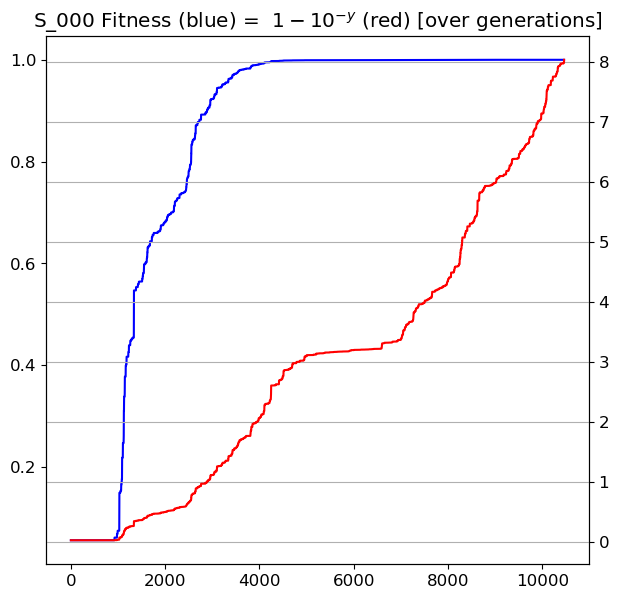

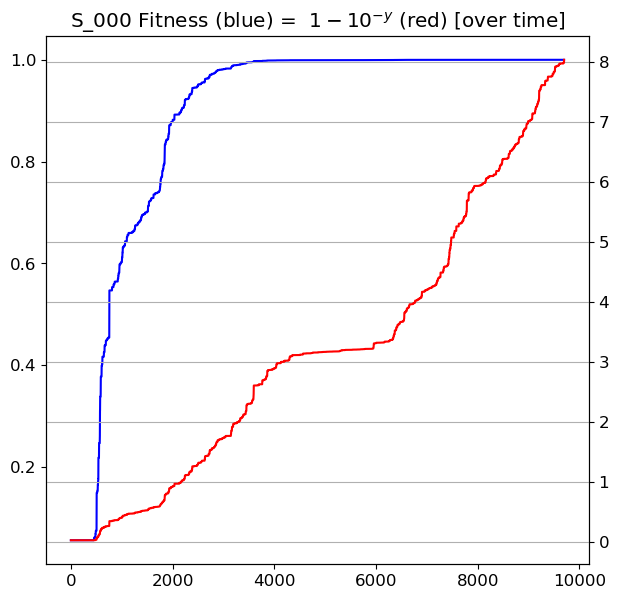

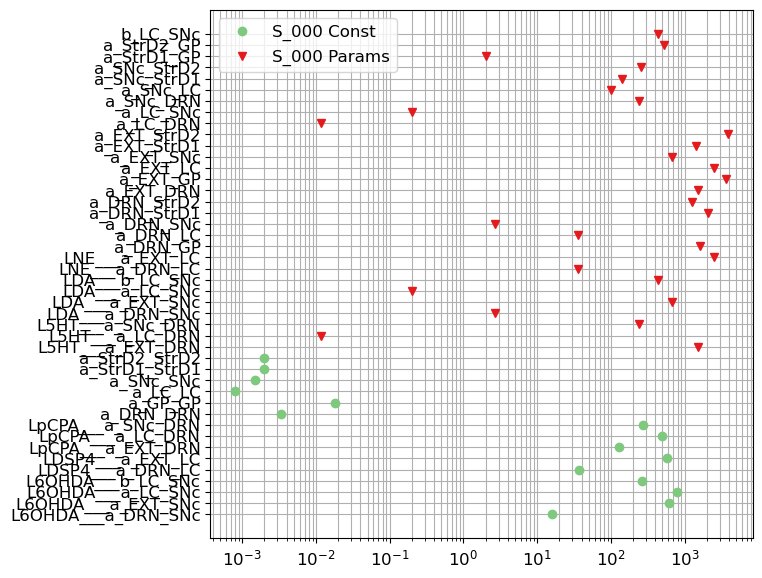

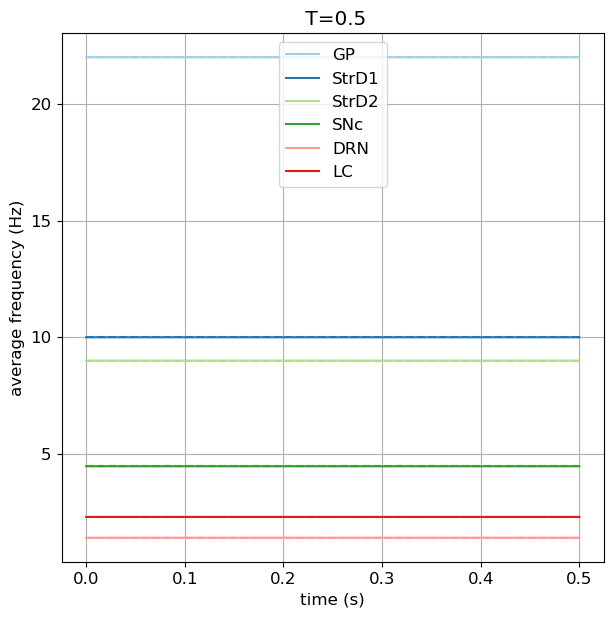

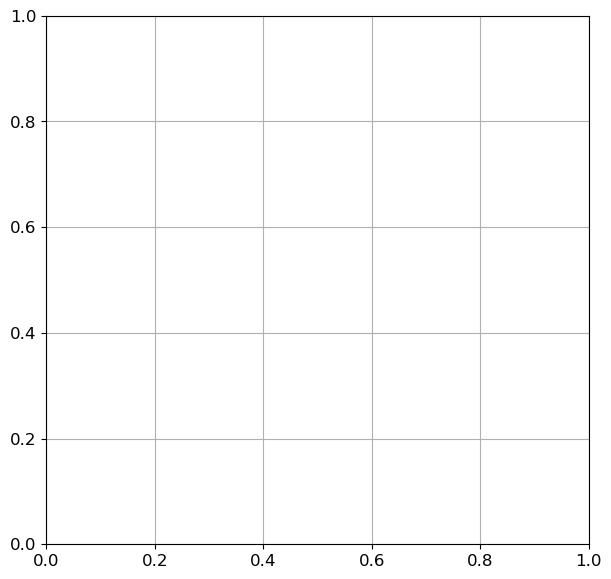

In [2]:
s01_subj_zero_fit(fit=False, plot=True)

In [ ]:
s02_target_fitted_population(fit=False, plot=True)

In [ ]:
s03_parameter_sensitivity_analysis(fit=False, plot=True)

In [ ]:
s04_the_cure(fit=False, plot=True)

In [ ]:
s05_statistics(fit=False, plot=True)

In [ ]:
from s02_population import *
files = sorted(filter(lambda x: x.startswith('S_'), os.listdir(POPULATION_BASE_PATH + '')))
individuals = [Healthy_combined_fit.load(POPULATION_BASE_PATH + '%s' % f) for f in files]
people_in_population = len(individuals)

res = list()
for i in individuals:
    a = i.P['a_LC_SNc']
    b = i.P['b_LC_SNc']
    lc = i['target']['LC']
    z_ind = 0 if a/(2*b) - lc >= 0 else 1000
#     z = a/(2*b) - lc
    z = -a + 2*b*lc
    res.append([a,b,lc,-a*lc+b*lc**2,z_ind,z])

res = sorted(res, key=lambda x: x[3])
plt.plot([x[3] for x in res], label='effect')
# plt.plot([x[0] for x in res], label='a')
# plt.plot([x[1] for x in res], label='b')
# plt.plot([x[2] for x in res], label='lc')
plt.plot([x[5] for x in res], label='derivative value')
plt.grid()
plt.legend()
plt.yscale('symlog')
plt.show()



In [ ]:
res = sorted(res, key=lambda x: x[5])
plt.plot([x[3] for x in res], label='effect')
plt.plot([x[5] for x in res], label='derivative value')
plt.yscale('symlog')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# a = 200
# b = 100
# lc = 2.4
# base = np.arange(0,3,0.01)
# f = lambda x: -a*x+b*x**2
# plt.plot(base, f(base))
# plt.grid()

base = np.arange(0,3,0.01)
res = sorted(res, key=lambda x: x[5])
samples = res[::20]
for a,b,lc,r,z_ind,z in samples:
    plt.figure()
    f = lambda x: -a*x+b*x**2
    fp = lambda x: -a + 2*b*x
    fbase = f(base)
    fpbase = fp(base)
    allvalues = list(fbase)+list(fpbase)
    plt.plot(base, fbase, label='effect')
    plt.plot(base, fpbase, label='derivative')
    plt.plot([lc,lc],[min(allvalues),max(allvalues)], label='lc')
    plt.legend()
    plt.grid()